# Comparativa de Clustering: K-Means, DBSCAN y Jerárquico

**Objetivo:** comparar tres métodos de clustering en un dataset real y elegir **el mejor** según el **coeficiente de silueta** (y **Elbow** solo para K-Means).

**Dataset elegido:** **Palmer Penguins** (medidas de pingüinos) — datos libres y fáciles de obtener.

- Página del proyecto: <https://allisonhorst.github.io/palmerpenguins/>
- CSV directo (penguins_clean): <https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins_clean.csv>

> Nota: **NO uses la columna de especie** (`species`) para entrenar (clustering es no supervisado). Se puede usr más tarde sólo para **interpretación** si lo deseas, pero **nunca** para ajustar los modelos.


## Requisitos
- Trabajar siempre con **variables numéricas** y **datos escalados**.
- Evaluación:
  - **K-Means:** curva **Elbow** (inercia) para k=2..10 + **Silhouette** para k=2..10.
  - **DBSCAN:** probar varias combinaciones de `eps` y `min_samples`; reportar **Silhouette**, nº de clústeres (excl. ruido) y % ruido.
  - **Jerárquico:** probar `linkage` en {`ward`, `complete`, `average`} y k=2..10; reportar **Silhouette**.
- Conclusión final: elige método y configuración (parámetros) y justifica **en 8–12 líneas**.

**Importante (API de scikit-learn):**
- `KMeans` **sí** tiene `.predict(X)` para etiquetar nuevos puntos.
- `DBSCAN` y `AgglomerativeClustering` **no** tienen `.predict`. Usa `fit_predict(X)` y el atributo `.labels_` tras el ajuste.


## 0) Preparación del entorno
- Necesitas tener instalado `pandas`, `numpy`, `scikit-learn`, `matplotlib`.
- Fija `random_state=42` (u otro) cuando aplique para reproducibilidad.


In [8]:
#IMPORTACIÓN DE LIBRERÍAS 
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

ENLACE AL CSV QUE FUNCIONA: 

https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv

## 1) Descarga y carga de datos
1. Descarga el CSV desde la URL indicada.
2. Cárgalo en un `DataFrame`.
3. Inspecciona forma, nombres de columnas y tipos.
4. Identifica columnas **numéricas** que usarás como `X` (excluye `species` y otras no numéricas).


In [14]:
# -------DESCARGA Y CARGA DEL CSV-------------

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)
df = df.dropna()
df = df.drop_duplicates()

In [10]:
# ---- Mostrar df.head()---------

print("=== Primeras filas del DataFrame ===")
df.head()

=== Primeras filas del DataFrame ===


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [11]:
#---------------- Mostrar df.info()----------------

print("\n=== Información del DataFrame ===")
df.info()


=== Información del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [12]:
#------------- Mostrar df.describe()---------------

print("\n=== Estadísticas descriptivas ===")
df.describe()


=== Estadísticas descriptivas ===


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## 2) Limpieza mínima y normalización
1. Elimina duplicados y filas con nulos en las columnas numéricas escogidas.
2. **Estandariza** (`StandardScaler`) para tener media 0 y varianza 1.
3. Guarda el array escalado como `X_scaled` (será tu base para todos los modelos).

> **Por qué escalamos:** Todas las distancias (Euclídeas) y medidas de densidad de los modelos dependen de la escala; mezclar variables en escalas distintas sesga los resultados.


In [17]:
# TODO: Limpieza básica (drop_duplicates / dropna) y escalado con StandardScale
# Eliminamos duplicados y filas con NaN (limpieza simple) ----> hecho arriba al cargar datos
X = df.select_dtypes(include=[np.number])  # Seleccionamos solo columnas numéricas
# Escalado de los datos numéricos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# RESULTADOS
print("Columnas de X:")
print(list(X.columns))
print(X.shape, '->', X_scaled.shape)

# Mostrar primeras filas escaladas (opcional)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

Columnas de X:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
(333, 4) -> (333, 4)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


## 3) K-Means
**Objetivo:**
- Bucle `k` en 2..10.
- Guardar por cada `k`: **inercia** (suma de distancias al centroide) y **Silhouette**.
- Seleccionar `k` final apoyándote en **Elbow** + **Silhouette**.

**Indicaciones específicas:**
- Usa `KMeans(n_clusters=k, random_state=42)`.
- Tras ajustar, obtén etiquetas con `.labels_` o usando `.predict(X_scaled)`.
- Para Silhouette: `sklearn.metrics.silhouette_score(X_scaled, labels)`.
- Traza **Inercia vs k** y **Silhouette vs k** (dos gráficos separados). Explica en 2-3 líneas tu elección de `k`.


In [ ]:
# TODO: Bucle K-Means para k=2..10, guardar inercia y silhouette
# TODO: Graficar Elbow (inercia vs k) y Silhouette vs k
# TODO: Elegir k_final y ajustar modelo final; obtener labels_kmeans


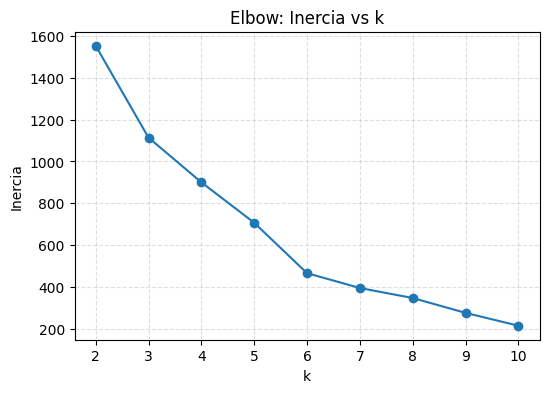

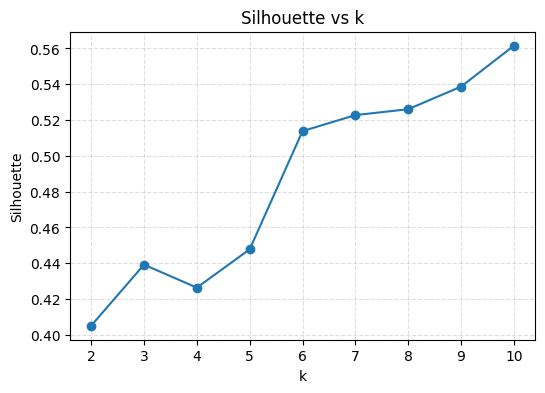

Tamaño por clúster: [24 61 28 29 22 32 34 58 23 22]


In [ ]:
# K-Means con X escalada

ks = range(2, 11)
inertias = []
sil_scores = []
labels_per_k = {}

for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    labels = km.labels_  # o km.predict(X_scaled)
    labels_per_k[k] = labels
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# --- Gráfico 1: Elbow (Inercia vs k)
plt.figure(figsize=(6,4))
plt.plot(list(ks), inertias, "o-")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Elbow: Inercia vs k")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# --- Gráfico 2: Silhouette vs k
plt.figure(figsize=(6,4))
plt.plot(list(ks), sil_scores, "o-")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# --- Elección de k apoyada en Elbow + Silhouette ---

# Convertimos la lista de inercias a array NumPy (más fácil de manipular numéricamente)
inertias_arr = np.array(inertias, dtype=float)

# Calculamos la 2ª diferencia discreta de la inercia.
# Esto mide cómo cambia la pendiente entre valores consecutivos (curvatura de la gráfica).
# En el método del "Elbow", buscamos donde la curvatura es máxima (el "codo" más pronunciado).
sec_diff = np.diff(inertias_arr, n=2)

# Obtenemos el índice donde la curvatura (negativa) es máxima.
# np.argmax(-sec_diff) da la posición del codo.
# Sumamos +2 porque np.diff con n=2 reduce la longitud en 2 (ajuste de índice).
k_elbow = list(ks)[np.argmax(-sec_diff) + 2]

# Obtenemos el valor de k con mayor Silhouette score.
# Silhouette mide qué tan separados y compactos están los clústeres (mayor es mejor).
k_sil = list(ks)[int(np.argmax(sil_scores))]

# k_elbow → sugiere el "codo" en la inercia
# k_sil   → sugiere la mejor separación entre clústeres
# Ambos se usan como referencia para elegir k_final

# Priorizamos silhouette y reportamos ambos
k_final = k_sil
kmeans_final = KMeans(n_clusters=k_final, random_state=42).fit(X_scaled)
labels_kmeans = kmeans_final.labels_

# (opcional) tamaño de cada clúster
print("Tamaño por clúster:", np.bincount(labels_kmeans))


Método del Elbow:
Puedo observar que en el punto en el que más se observa un vambio brusco es en el k = 6

Método de Silhouette:
El valor máximo está en k = 10, pero es un valor demasiado elevado comparando con la gráfica Elbow vs k. Sin embargo, teniendo en cuenta el valor de la k máxima de la gráfica anterior, k=6 es un pico máximo también.

## 4) DBSCAN
**Objetivo:** explorar `eps` y `min_samples` en una rejilla pequeña y comparar resultados.

**Indicaciones específicas:**
- Probar `eps` en valores razonables (por ejemplo: 0.3, 0.5, 0.7, 0.9) y `min_samples` en {3, 5, 7}.
- Para cada combinación: ajusta con `DBSCAN(eps=?, min_samples=?)` sobre `X_scaled`.
- Extrae etiquetas con `.labels_`.
- Calcula **nº de clústeres** (excluyendo `-1`) y **% de ruido** (`label == -1`).
- Calcula **Silhouette** **solo si** hay al menos **2** clústeres válidos (sin contar ruido). Si no, anota "no aplicable".
- Elige una combinación final y justifica.


In [ ]:
# TODO: Grid pequeño de DBSCAN: probar eps y min_samples
# TODO: Para cada combinación, registrar #clusters válidos, %ruido y silhouette (si aplica)
# TODO: Elegir configuración final; obtener labels_dbscan


In [ ]:
# Rejilla de búsqueda (sobre X_scaled)
eps_values = [0.3, 0.5, 0.7, 0.9]
min_samples_values = [3, 5, 7]

resultados = []
modelos = {}    

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s).fit(X_scaled)
        labels = db.labels_
        modelos[(eps, min_s)] = db

        # nº de clústeres válidos (sin contar ruido = -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        # % de ruido
        noise_pct = (labels == -1).mean() * 100

        # Silhouette solo si hay al menos 2 clústeres válidos
        sil = silhouette_score(X_scaled, labels) if n_clusters >= 2 else np.nan

        resultados.append({
            "eps": eps,
            "min_samples": min_s,
            "n_clusters": n_clusters,
            "noise_pct": round(noise_pct, 2),
            "silhouette": sil
        })

df_dbscan = pd.DataFrame(resultados)
print("Resultados DBSCAN (rejilla):")
display(df_dbscan)

# ===== Elección de configuración final =====
# Regla: priorizamos mayor silhouette; a igualdad, menor ruido; luego mayor nº de clústeres
validos = df_dbscan.dropna(subset=["silhouette"])
if not validos.empty:
    best = validos.sort_values(
        by=["silhouette", "noise_pct", "n_clusters"],
        ascending=[False, True, False]
    ).iloc[0]
else:
    # Si ninguna combinación tiene >=2 clústeres válidos, priorizamos más clústeres y menos ruido
    best = df_dbscan.sort_values(
        by=["n_clusters", "noise_pct"],
        ascending=[False, True]
    ).iloc[0]

eps_best = float(best["eps"])
min_s_best = int(best["min_samples"])
dbscan_final = modelos[(eps_best, min_s_best)]
labels_dbscan = dbscan_final.labels_

# Resumen textual corto (puedes guardarlo/mostrarlo)
sil_txt = "no aplicable" if np.isnan(best["silhouette"]) else f"{best['silhouette']:.3f}"
print(
    f"Configuración elegida: eps={eps_best}, min_samples={min_s_best} | "
    f"clusters={int(best['n_clusters'])}, ruido={best['noise_pct']}%, silhouette={sil_txt}"
)
print("labels_dbscan (primeras 20):", labels_dbscan[:20])

Resultados DBSCAN (rejilla):


,eps,min_samples,n_clusters,noise_pct,silhouette
0,0.3,3,15,78.98,-0.302241
1,0.3,5,1,98.50,NaN
2,0.3,7,0,100.00,NaN
3,0.5,3,17,33.63,0.138727
4,0.5,5,8,47.15,0.090005
5,0.5,7,5,56.16,0.114776
6,0.7,3,12,9.31,0.411786
7,0.7,5,9,15.92,0.397890
8,0.7,7,9,21.62,0.336196
9,0.9,3,9,1.80,0.542024


Configuración elegida: eps=0.9, min_samples=3 | clusters=9, ruido=1.8%, silhouette=0.542
labels_dbscan (primeras 20): [ 0  1  1  1  0  1  0  1  0 -1  1  1  0  1  0  2  3  2  3  3]


Observando el resto de combinaciones comprobamos que es el que tiene mejor puntuación de Silhouette, indicandonos que es la estructura más clara y coherente.
Respecto al procentaje de ruido también es qur menos valor presenta, el número de clusters obtenidos es el más pequeño siendo capaz de agrupar todos los puntos en el menor numero de clusters y teniendo el mejor valor de Silhouette. 

## 5) Aglomerativo Jerárquico
**Objetivo:** probar distintas reglas de enlace y diferentes `k`.

**Indicaciones específicas:**
- Probar `linkage` en {`ward`, `complete`, `average`}.
- Para cada `linkage`, probar `n_clusters` en 2..10.
- Ajustar con `AgglomerativeClustering(n_clusters=k, linkage=..., metric='euclidean')`.
- Obtener etiquetas con `.fit_predict(X_scaled)` o del atributo `.labels_`.
- Calcular **Silhouette** y registrar los resultados en una tabla.
- Elegir la pareja (linkage, k) final y justificar.

> Recordatorio: `ward` requiere métrica euclídea (en scikit-learn es implícita). No hay `.predict()` para nuevos datos.


In [ ]:
# TODO: Bucle Agglomerative: linkage en {'ward','complete','average'} y k=2..10
# TODO: Calcular silhouette para cada combinación y elegir la mejor; obtener labels_agglom


In [ ]:
# =========================
# 5) Aglomerativo Jerárquico: grid linkage∈{'ward','complete','average'}, k=2..10
# =========================
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

linkages = ['ward', 'complete', 'average']
ks = range(2, 11)

resultados_agglom = []

for link in linkages:
    for k in ks:
        # Nota: 'ward' fuerza distancia euclídea; en sklearn es implícita (no pases metric para evitar warning)
        if link == 'ward':
            model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage=link, metric='euclidean')

        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan

        resultados_agglom.append({
            "linkage": link,
            "k": k,
            "silhouette": sil
        })

# Tabla de resultados
df_agglom = pd.DataFrame(resultados_agglom).sort_values(["linkage", "k"]).reset_index(drop=True)
print("Resultados Agglomerative (Silhouette por combinación):")
display(df_agglom)

# ===== Selección de la mejor pareja (linkage, k) por máximo silhouette =====
best_idx = df_agglom['silhouette'].idxmax()
best_link = df_agglom.loc[best_idx, 'linkage']
best_k = int(df_agglom.loc[best_idx, 'k'])
best_sil = df_agglom.loc[best_idx, 'silhouette']

# Ajuste final y etiquetas
if best_link == 'ward':
    best_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
else:
    best_model = AgglomerativeClustering(n_clusters=best_k, linkage=best_link, metric='euclidean')

labels_agglom = best_model.fit_predict(X_scaled)

print(f"Configuración elegida: linkage='{best_link}', k={best_k}, silhouette={best_sil:.3f}")
print("labels_agglom (primeras 20):", labels_agglom[:20])


Resultados Agglomerative (Silhouette por combinación):


,linkage,k,silhouette
0,average,2,0.405135
1,average,3,0.442014
2,average,4,0.471413
3,average,5,0.413366
4,average,6,0.465452
5,average,7,0.474574
6,average,8,0.509948
7,average,9,0.525355
8,average,10,0.545920
9,complete,2,0.405135


Configuración elegida: linkage='complete', k=10, silhouette=0.560
labels_agglom (primeras 20): [6 8 8 8 6 8 6 8 6 6 8 8 6 8 6 2 7 2 7 7]


## 6) Comparativa y Conclusión
1. Resume en una **tabla** el **mejor** resultado de cada método (método, parámetros, silhouette, nº de clústeres y notas relevantes como % ruido en DBSCAN).
2. Escribe una **conclusión de 8–12 líneas** justificando el **método ganador** para estos datos y por qué descartas las alternativas (forma de clústeres, sensibilidad a parámetros, presencia de ruido/outliers, etc.).


In [ ]:
# TODO: Construir la tabla comparativa final y redactar la conclusión (puedes imprimir un markdown)

In [ ]:
# TABLA RESUMEN MEJORES MODELOS (KMeans, DBSCAN, Agglomerativo)

# --- K-MEANS (usa resultados previos del barrido) ---
kmeans_best_k = int(k_sil)  # ya elegiste priorizando silhouette
kmeans_sil    = float(np.max(sil_scores))
kmeans_k_cnt  = len(np.unique(labels_kmeans))
kmeans_notes  = f"Elbow≈{k_elbow}; elegido por Silhouette (k={kmeans_best_k})"

# --- DBSCAN (usa 'best' y 'labels_dbscan' del grid) ---
dbscan_best_eps   = float(eps_best)
dbscan_best_min_s = int(min_s_best)
dbscan_sil        = (np.nan if pd.isna(best['silhouette']) else float(best['silhouette']))
dbscan_k_cnt      = int(best['n_clusters'])
dbscan_noise      = float(best['noise_pct'])
dbscan_notes      = f"Ruido={dbscan_noise}%; eps={dbscan_best_eps}, min_samples={dbscan_best_min_s}"

# --- AGGLOMERATIVO (usa mejor combinación seleccionada) ---
agglom_best_link = str(best_link)
agglom_best_k    = int(best_k)
agglom_sil       = float(best_sil)
agglom_k_cnt     = len(np.unique(labels_agglom))
agglom_notes     = f"linkage='{agglom_best_link}'"

# --- Construcción del DataFrame resumen ---
df_resumen = pd.DataFrame([
    {
        "método": "K-Means",
        "parámetros": f"k={kmeans_best_k}",
        "silhouette": round(kmeans_sil, 3),
        "n_clústeres": kmeans_k_cnt,
        "notas": kmeans_notes
    },
    {
        "método": "DBSCAN",
        "parámetros": f"eps={dbscan_best_eps}, min_samples={dbscan_best_min_s}",
        "silhouette": ("no aplicable" if pd.isna(dbscan_sil) else round(dbscan_sil, 3)),
        "n_clústeres": dbscan_k_cnt,
        "notas": f"{dbscan_notes}"
    },
    {
        "método": "Aglomerativo",
        "parámetros": f"linkage={agglom_best_link}, k={agglom_best_k}",
        "silhouette": round(agglom_sil, 3),
        "n_clústeres": agglom_k_cnt,
        "notas": agglom_notes
    }
])

print("Resumen de mejores configuraciones por método:")
display(df_resumen)


Resumen de mejores configuraciones por método:


,método,parámetros,silhouette,n_clústeres,notas
0,K-Means,k=10,0.562,10,Elbow≈6; elegido por Silhouette (k=10)
1,DBSCAN,"eps=0.9, min_samples=3",0.542,9,"Ruido=1.8%; eps=0.9, min_samples=3"
2,Aglomerativo,"linkage=complete, k=10",0.560,10,linkage='complete'


Observando los resultados por un lado tenemos que el mejor valor de Silhouette es el de K-Means, sin embargo tiene el mismo número de clausters que el Aglomerativo. 
Por otro lado, el de DBSCAN es el que menos clauesters tiene 1 clauster menos que el resto teniendo el peor numero de Silhouette (aunque por poca distancia).

Finalmente, el método que voy a elegir es el 1º (K-Means), a pesar de tener 10 clausters.

---
## Tips rápidos
- **Escala siempre** antes de ajustar los modelos.
- Si la Silhouette es negativa o muy baja, revisa parámetros.
- En DBSCAN, `eps` muy pequeño -> muchos ruidos; `eps` muy grande -> pocos clústeres (puede mezclarlo todo).
- K-Means es sensible a outliers; DBSCAN puede marcarlos como ruido; el jerárquico con `complete` favorece clústeres compactos.
- Documenta tus decisiones (por qué ese `k`, ese `eps`, ese `linkage`).


# BONUS EXTRA

### Validación tramposa

Usa la columna species para evaluar qué tan “puras” son las asignaciones del mejor modelo de cada método.

Creando una matriz de confusión entre clúster y especie y sacando accuracy.

Comenta usando distintos valores de eps y min_samples en DBSCAN.

### Detección de anomalías con DBSCAN

Con tu configuración de DBSCAN, analiza los puntos con label = -1 (ruido): ¿qué tienen en común (rangos extremos de masa, culmen, etc.)?

Genera una tabla o un par de graficas (histogramas comparativos, por ejemplo) para ilustrar las diferencias entre los puntos de ruido y los puntos asignados a clústeres.
